# CBR Diet Recommendation 



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 1. Load & Cleaning

Langkah pembersihan (mengisi missing, standarisasi teks, validasi rentang numerik, hapus duplikat).

In [3]:
df_diet = pd.read_csv('diet_recommendations_dataset.csv')

# Isi missing kategorikal
df_diet['Disease_Type'] = df_diet['Disease_Type'].fillna('None')
df_diet['Dietary_Restrictions'] = df_diet['Dietary_Restrictions'].fillna('None')
df_diet['Allergies'] = df_diet['Allergies'].fillna('None')

# Standarisasi teks -> lowercase + strip
text_cols = ['Gender', 'Disease_Type', 'Severity', 'Physical_Activity_Level',
             'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine',
             'Diet_Recommendation']
for col in text_cols:
    df_diet[col] = df_diet[col].astype(str).str.strip().str.lower()

# Rename agar konsisten
df_diet.rename(columns={
    'Patient_ID': 'patient_id',
    'Cholesterol_mg/dL': 'Cholesterol',
    'Glucose_mg/dL': 'Glucose'
}, inplace=True)

# Validasi rentang fisik
df_diet = df_diet[
    (df_diet['BMI'].between(10, 80)) &
    (df_diet['Age'].between(1, 120)) &
    (df_diet['Weekly_Exercise_Hours'].between(0, 168))
]
df_diet = df_diet.drop_duplicates()

print('Shape setelah cleaning :', df_diet.shape)
print('Distribusi target Diet_Recommendation:')
print(df_diet['Diet_Recommendation'].value_counts())


Shape setelah cleaning : (1000, 20)
Distribusi target Diet_Recommendation:
Diet_Recommendation
balanced      426
low_sodium    316
low_carb      258
Name: count, dtype: int64


## 2. Seleksi & penamaan kolom (skema lowercase)

In [4]:
df_cbr = df_diet.rename(columns={
    'Age': 'age',
    'Gender': 'gender',
    'Weight_kg': 'weight_kg',
    'Height_cm': 'height_cm',
    'BMI': 'bmi',
    'Disease_Type': 'disease_type',
    'Cholesterol': 'cholesterol',
    'Glucose': 'glucose',
    'Blood_Pressure_mmHg': 'blood_pressure',
    'Diet_Recommendation': 'diet_recommendation',
})[['patient_id', 'age', 'gender', 'bmi', 'disease_type',
    'cholesterol', 'glucose', 'blood_pressure', 'diet_recommendation']].copy()

# Pastikan numerik benar-benar numerik, isi NaN dengan median
num_check = ['age', 'bmi', 'cholesterol', 'glucose', 'blood_pressure']
for c in num_check:
    df_cbr[c] = pd.to_numeric(df_cbr[c], errors='coerce')
    df_cbr[c] = df_cbr[c].fillna(df_cbr[c].median())

print('df_cbr shape:', df_cbr.shape)
df_cbr.head()


df_cbr shape: (1000, 9)


,patient_id,age,gender,bmi,disease_type,cholesterol,glucose,blood_pressure,diet_recommendation
0,P0001,56,male,22.8,obesity,173.3,116.3,133,balanced
1,P0002,69,male,35.4,diabetes,199.2,137.1,120,low_carb
2,P0003,46,female,21.2,hypertension,181.0,109.6,121,low_sodium
3,P0004,32,male,21.6,none,168.2,159.4,144,balanced
4,P0005,60,male,20.5,diabetes,200.4,182.3,172,low_carb


## 3. Definisi 6 Fitur Berbobot (CBR)

| Fitur | Bobot |
|---|---|
| disease_type | 0.30 |
| bmi | 0.20 |
| cholesterol | 0.15 |
| blood_pressure | 0.15 |
| age | 0.10 |
| glucose | 0.10 |


In [ ]:
weight_config = {
    'disease_type':   0.30,
    'bmi':            0.20,
    'cholesterol':    0.15,
    'blood_pressure': 0.15,
    'age':            0.10,
    'glucose':        0.10,
}
numeric_feats = ['bmi', 'cholesterol', 'blood_pressure', 'age', 'glucose']

X = df_cbr[['disease_type'] + numeric_feats].copy()
y = df_cbr['diet_recommendation'].copy()

# One-hot disease_type (dinamis sesuai kategori yang ada)
X = pd.get_dummies(X, columns=['disease_type'], prefix='disease_type')
disease_cols = [c for c in X.columns if c.startswith('disease_type_')]
print('Kolom disease_type hasil one-hot:', disease_cols)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('\nMapping target:')
for i, c in enumerate(le.classes_):
    print(f'  {c} -> {i}')


Kolom disease_type hasil one-hot: ['disease_type_diabetes', 'disease_type_hypertension', 'disease_type_none', 'disease_type_obesity']

Mapping target:
  balanced -> 0
  low_carb -> 1
  low_sodium -> 2


## 4. Split data + scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

X_train = X_train.copy()
X_test = X_test.copy()

# MinMax di-fit HANYA pada train
scaler = MinMaxScaler()
X_train[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test[numeric_feats]  = scaler.transform(X_test[numeric_feats])

# Pastikan kolom one-hot bertipe float
X_train[disease_cols] = X_train[disease_cols].astype(float)
X_test[disease_cols]  = X_test[disease_cols].astype(float)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)


X_train: (800, 9) | X_test: (200, 9)


## 5. Vektor bobot per kolom

Bobot `disease_type` (0.30) dibagi rata ke seluruh kolom dummy disease, lalu seluruh bobot dinormalisasi agar berjumlah 1.

In [7]:
col_weights = {f: weight_config[f] for f in numeric_feats}
for c in disease_cols:
    col_weights[c] = weight_config['disease_type'] / len(disease_cols)

total = sum(col_weights.values())
col_weights = {k: v / total for k, v in col_weights.items()}

feature_order = numeric_feats + disease_cols
w_vec = np.array([col_weights[f] for f in feature_order], dtype=float)

Xtr = X_train[feature_order].to_numpy(dtype=float)
Xte = X_test[feature_order].to_numpy(dtype=float)
ytr = np.asarray(y_train)
yte = np.asarray(y_test)

print('Bobot per kolom (sudah dinormalisasi):')
for f in feature_order:
    print(f'  {f:35s}: {col_weights[f]:.4f}')


Bobot per kolom (sudah dinormalisasi):
  bmi                                : 0.2000
  cholesterol                        : 0.1500
  blood_pressure                     : 0.1500
  age                                : 0.1000
  glucose                            : 0.1000
  disease_type_diabetes              : 0.0750
  disease_type_hypertension          : 0.0750
  disease_type_none                  : 0.0750
  disease_type_obesity               : 0.0750


## 6. Retrieval CBR — Weighted Euclidean Distance + majority vote

cari `k` kasus paling mirip berdasarkan jarak Euclidean berbobot, lalu ambil mayoritas (tie-break berdasarkan rata-rata jarak terdekat).

In [8]:
def predict_weighted_knn(Xte, Xtr, ytr, w_vec, k=5):
    preds = []
    for q in Xte:
        dist = np.sqrt(np.sum(w_vec * (Xtr - q) ** 2, axis=1))
        idx = np.argsort(dist)[:k]
        labels = ytr[idx]
        # voting + tie-break: jumlah suara terbanyak, jika seri pilih rata-rata jarak terkecil
        vals, counts = np.unique(labels, return_counts=True)
        top = vals[counts == counts.max()]
        if len(top) == 1:
            preds.append(int(top[0]))
        else:
            best, best_d = None, np.inf
            for v in top:
                md = dist[idx][labels == v].mean()
                if md < best_d:
                    best, best_d = v, md
            preds.append(int(best))
    return np.array(preds)


## 7. Cari k terbaik

Percobaan beberapa nilai k dan dipilih yang terbaik.

 k  accuracy
 1       1.0
 3       1.0
 5       1.0
 7       1.0
 9       1.0
11       1.0
15       1.0
21       1.0

k terbaik: 1


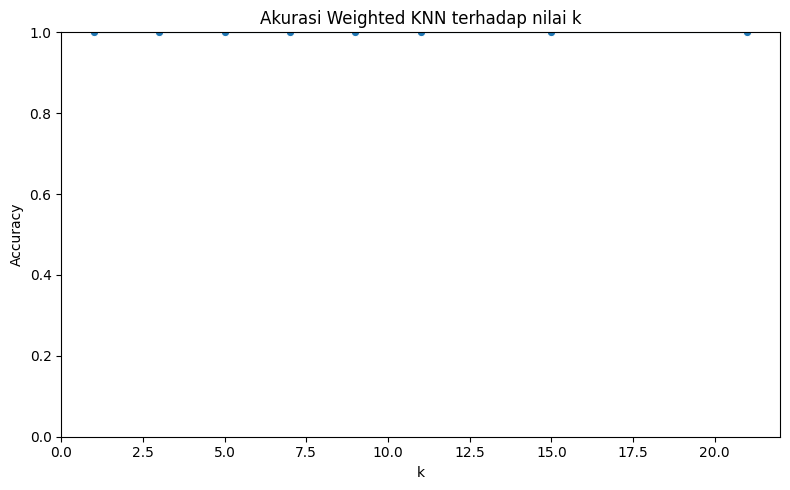

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
rows = []
for k in k_values:
    yp = predict_weighted_knn(Xte, Xtr, ytr, w_vec, k=k)
    rows.append({'k': k, 'accuracy': accuracy_score(yte, yp)})

k_df = pd.DataFrame(rows)
best_k = int(k_df.loc[k_df['accuracy'].idxmax(), 'k'])
print(k_df.to_string(index=False))
print(f'\nk terbaik: {best_k}')

plt.figure(figsize=(8, 5))
sns.lineplot(data=k_df, x='k', y='accuracy', marker='o')
plt.title('Akurasi Weighted KNN terhadap nilai k')
plt.xlabel('k'); plt.ylabel('Accuracy'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()


## 8. Evaluasi final dengan k terbaik

=== WEIGHTED KNN (CBR) — EVALUASI FINAL ===
k        : 1
Accuracy : 1.0000 (100.00%)

=== Classification Report ===
              precision    recall  f1-score   support

    balanced       1.00      1.00      1.00        85
    low_carb       1.00      1.00      1.00        52
  low_sodium       1.00      1.00      1.00        63

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



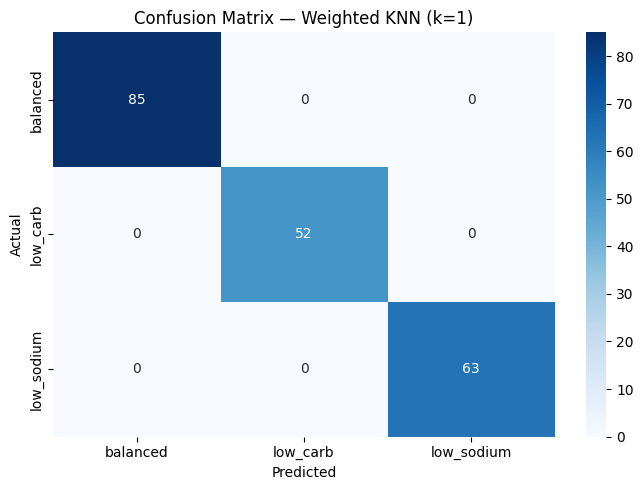

In [10]:
y_pred = predict_weighted_knn(Xte, Xtr, ytr, w_vec, k=best_k)
acc = accuracy_score(yte, y_pred)

print('=== WEIGHTED KNN (CBR) — EVALUASI FINAL ===')
print(f'k        : {best_k}')
print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)\n')
print('=== Classification Report ===')
print(classification_report(yte, y_pred, target_names=le.classes_))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(yte, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — Weighted KNN (k={best_k})')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()


## 9. Penyimpanan Base Case hasil Preprocessing

In [14]:
# concat X_train, X_test, y_train, y_test dan jadikan dataframe utuh, jangan yang weighted
X_train_full = pd.concat([X_train, X_test], ignore_index=True)
y_train_full = np.concatenate([y_train, y_test])
df_full = X_train_full.copy()
df_full['diet_recommendation'] = y_train_full
df_full.to_csv('diet_case_base.csv', index=False)